# Mark-0 COVID Heterogeneous-Agent ABM

Mark-0 {cite:t}`BouchaudGualdiTarziaZamponi2018OptimalInflation` is a
closed-economy ABM with $N$ firms, one representative household, one
commercial bank, and one central bank. The COVID extension
{cite:p}`SharmaBouchaudGualdiTarziaZamponi2021COVID` adds the
parameter set used to study V-, U-, L-, and W-shaped recovery
regimes. Each macro period executes an ordered 24-phase loop:
price/wage adjustment, hiring/firing, production, household
consumption, interest-rate setting, bankruptcy, and firm revival.

Stochastic phases are reparameterised through three independent
frozen $U(0, 1)$ noise buffers of shape ``(timesteps, N_firms)``
pre-drawn in ``initialize()``. Boundary conditions on the two
gradient-critical paths (``stay_alive`` indicator and the positive-$Y$
guard) use ``Behavior.diffwhere``; all other branches use plain
``torch.where``, matching the abmstat reference pattern.

## Module Contents

Mark0COVID is divided into Variables, Parameters (fixed constants),
Scenarios, and the Behavior (model initialization and steps). See the
sibling pages linked from the model index for the per-component
tables.

## Implementation in MacroStat

The forward pass is differentiable end-to-end. The 24-phase loop is
decomposed into named methods on ``BehaviorMark0COVID`` so that each
phase carries its own docstring and ``Equations`` section.
``ParametersMark0COVID.get_default_hyperparameters`` sets
``dtype = torch.float64`` to match the abmstat reference precision.

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

from matplotlib import pyplot as plt

from macrostat.models.Mark0COVID import Mark0COVID, ParametersMark0COVID

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

### Four Gualdi phases

{cite:t}`GualdiTarziaZamponiBouchaud2015TippingPoints` show that the
Mark-0 long-run regime is determined by the location of $(R, \Theta)$
in the parameter plane, where $R = \eta_+/\eta_-$ is the
hiring/firing asymmetry and $\Theta$ is the bankruptcy default
threshold. Four phases occupy distinct regions:

- **FU** (Full Unemployment): $R < R_c$, the economy collapses to
  near-zero employment regardless of $\Theta$.
- **RU** (Residual Unemployment): $R > R_c$, low $\Theta$; firms
  default quickly so a non-trivial unemployment rate persists.
- **EC** (Endogenous Crises): $R > R_c$, intermediate $\Theta$;
  bankruptcy cascades trigger large oscillations between near-FE
  and near-FU regimes.
- **FE** (Full Employment): $R > R_c$, large $\Theta$; defaults are
  rare and the economy sits near full employment.

Each phase is realised as a distinct ``ParametersMark0COVID``
instance varying ``HiringFiringRate`` ($R$) and ``DefaultThreshold``
($\Theta$) only; all other parameters take their default values.

In [18]:
phases = {
    "FU (R=0.5, Theta=3)": (0.5, 3.0),
    "RU (R=2, Theta=0.5)": (2.0, 0.5),
    "EC (R=2, Theta=1.2)": (2.0, 1.2),
    "FE (R=2, Theta=5)": (2.0, 5.0),
}

paths = {}
for label, (R, Theta) in phases.items():
    params = ParametersMark0COVID(
        hyperparameters={"timesteps": 1000, "N_firms": 10000, "seed": 0},
    )
    params["HiringFiringRate"] = R
    params["DefaultThreshold"] = Theta
    model = Mark0COVID(parameters=params)
    model.simulate()
    paths[label] = model.variables.to_pandas()

### Unemployment trajectory

The aggregate unemployment series isolates the four phases at a
glance. FU collapses to $u \to 1$; RU settles at a positive
residual; EC oscillates between near-FE and near-FU bands; FE
converges close to full employment.

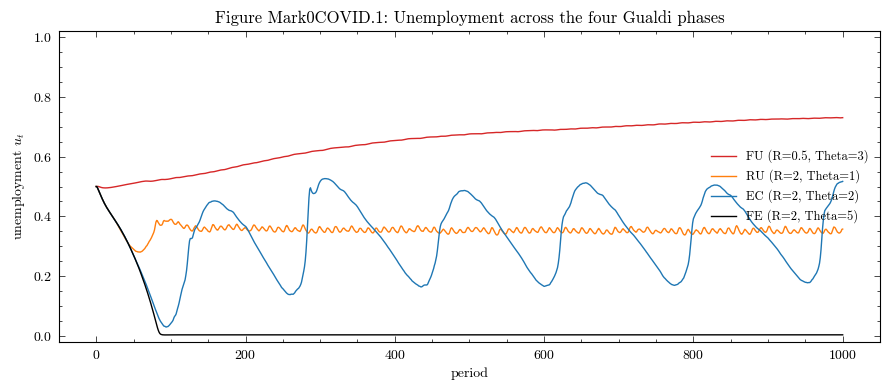

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:red", "tab:orange", "tab:blue", "k"]

for color, (label, df) in zip(colors, paths.items()):
    ax.plot(df.index, df["Unemployment"], color=color, linewidth=1.0, label=label)

ax.set_title("Figure Mark0COVID.1: Unemployment across the four Gualdi phases")
ax.set_xlabel("period")
ax.set_ylabel(r"unemployment $u_t$")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="center right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### Notes

- The shape of every het-agent state tensor in
  ``model.variables.timeseries`` is ``(T + 1, N_firms)``; aggregates
  are stored as ``(T + 1, 1)``. ``to_pandas()`` returns a multi-column
  DataFrame indexed by ``time``.